## QUESTION 1

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('top.50.songs.csv', encoding='latin-1')
print(df)

Saving top.50.songs.csv to top.50.songs.csv
    Unnamed: 0                                         Track.Name  \
0            1                                           Señorita   
1            2                                              China   
2            3                      boyfriend (with Social House)   
3            4                    Beautiful People (feat. Khalid)   
4            5                        Goodbyes (Feat. Young Thug)   
5            6                  I Don't Care (with Justin Bieber)   
6            7                                             Ransom   
7            8                                  How Do You Sleep?   
8            9                              Old Town Road - Remix   
9           10                                            bad guy   
10          11                                           Callaita   
11          12              Loco Contigo (feat. J. Balvin & Tyga)   
12          13                                  Someone You

In [ ]:
df.head()

,Unnamed: 0,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [ ]:
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')

,Unnamed: 0,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
Unnamed: 0,1.000000,-0.259193,0.102649,0.122691,0.011914,0.270659,0.137329,-0.065844,-0.015993,-0.257506,-0.160680
Beats.Per.Minute,-0.259193,1.000000,0.043756,-0.094183,0.017016,-0.167286,-0.011586,-0.139288,-0.031450,0.557052,0.196097
Energy,0.102649,0.043756,1.000000,0.018254,0.670794,0.162768,0.438820,0.224677,-0.339892,-0.089860,-0.080295
Danceability,0.122691,-0.094183,0.018254,1.000000,0.016255,-0.149636,0.172829,-0.000185,-0.098165,-0.103472,-0.071413
Loudness..dB..,0.011914,0.017016,0.670794,0.016255,1.000000,0.258652,0.237614,0.219219,-0.138300,-0.272213,-0.043085
Liveness,0.270659,-0.167286,0.162768,-0.149636,0.258652,1.000000,0.016123,0.131782,0.021328,-0.125286,0.092564
Valence.,0.137329,-0.011586,0.438820,0.172829,0.237614,0.016123,1.000000,-0.017782,-0.052323,-0.053242,-0.317752
Length.,-0.065844,-0.139288,0.224677,-0.000185,0.219219,0.131782,-0.017782,1.000000,-0.076293,0.046755,-0.087639
Acousticness..,-0.015993,-0.031450,-0.339892,-0.098165,-0.138300,0.021328,-0.052323,-0.076293,1.000000,0.008293,-0.034684
Speechiness.,-0.257506,0.557052,-0.089860,-0.103472,-0.272213,-0.125286,-0.053242,0.046755,0.008293,1.000000,0.238553


In [ ]:
# split into feature and target

X = df.drop(columns=["Popularity"])
y = df["Popularity"]

# QUESTION 2

In [ ]:
# train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 40
Testing rows: 10


## QUESTION 3

In [ ]:
# taking only danceability as feature

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x_small = df[["Danceability"]]
y_small = df["Popularity"]

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(x_small, y_small, test_size=0.95, random_state=40)

model = LinearRegression()
model.fit(X_train_small, y_train_small)

print("Train R²:", model.score(X_train_small, y_train_small))
print("Test R²:", model.score(X_test_small, y_test_small))

Train R²: 1.0
Test R²: -16.9075369075369


the training score is perfect but test score is extremely low. this is beacuse 5% of dataset was used, so it memorized the available data

## QUESTION 4

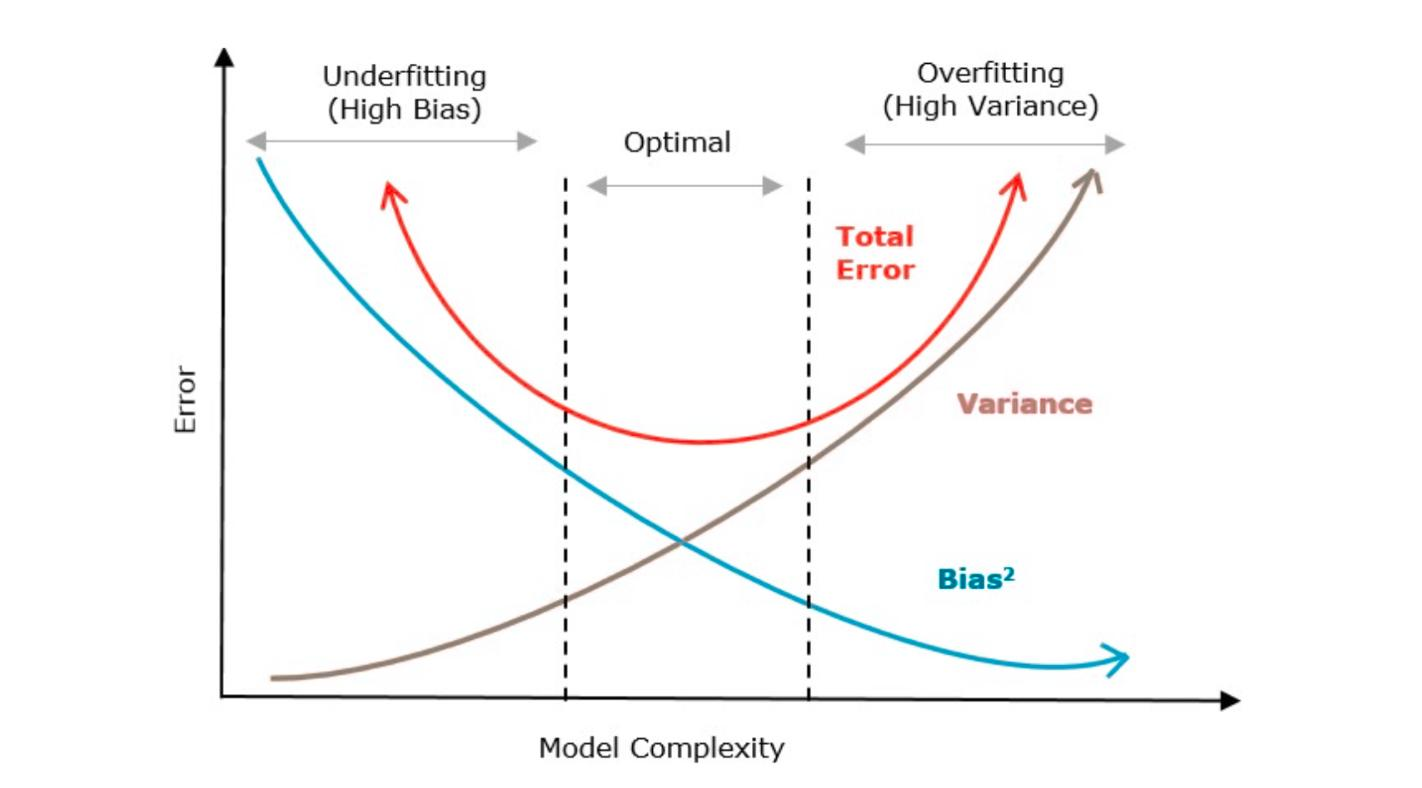

In [ ]:
from IPython.display import Image, display

display(Image("/content/5WvCiTAGFlxBbULx7ubb08ek2PWnmwgpTcXYDR69z-cFuWbkO7G8pJyZvX8C5qUYsCEQgnZ1sBlb2buZdzQNas35el3_eH2zXjf2XdOCZfYQ5S_EpX8ACD-tlur0aIuzvHBnKlgCm6VhQ8XVwZ1m3SuGb7IhKgtBMgqqcQASHejS-IKx-qKispe-vo-IchEB.jpg"))

# Bias-Variance Tradeoff

The bias-variance tradeoff describes the balance between underfitting and overfitting in a machine learning model. High bias leads to underfitting because the model is too simple, while high variance leads to overfitting because the model becomes too complex and memorizes the training data.

In a Zomato restaurant rating predictor app, a balanced model is needed to predict ratings accurately for both existing and new restaurants.


## QUESTION 5

real-world example of overfitting ?

 A good example of overfitting is in instagram recommendations. If you watch a few cooking videos in a short period, Instagram may start showing mostly cooking-related content and ignore your interests in travel, technology, or music.

This happens because the recommendation system may overfit to your recent activity instead of learning your overall preferences.
